# Exercise 4.2: Dangers of backtesting

Backtesting is the practice of simulating the performance of an investing strategy on historical data in order to see how the strategy would have performed had it been ran as history played out. Unfortnately, it turns out that the most common methods of backtesting are very prone to overfitting and spurious conclusions.

In this exercise we will look at an example of this happening, attempt to quantify this error, and finally look at an alternative method of studying the performance of our strategy.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations

from joblib import Parallel, delayed

Let us once again work with the dollar bar data from the first exercise. For the purposes of this exercise we will only be using the data from 2015.

In [4]:
df = pd.read_csv('./data/dollar_bars.csv', parse_dates=['datetime'], index_col='datetime')
df = df.loc['2015']
df.head()

,price
datetime,
2015-01-01 17:02:49.215,2057.5
2015-01-01 17:29:46.600,2058.5
2015-01-01 20:47:57.214,2061.5
2015-01-02 01:00:10.013,2063.9
2015-01-02 01:41:19.454,2064.4


Now let's suppose that we have come up with the following trading strategy based on two simple moving averages with different window sizes:

* Whenever the shorter moving average crosses above the longer one we buy a unit of the security.
* Whenever the opposite happens we sell a unit of security.
* We will never go short, nor will we take consecutive bets in the same direction. After a downturn we wait for the next upturn before participating in the market.

While this strategy is incredibly simplified, it is not uncommon to find people preaching similar strategies based on moving averages and other transformations of recent price history. The function calculates implements the above strategy and returns the total profit, as well as the realized return for every sale of the security.

In [5]:
def crossing(df, a, b):
    
    # Calculate rolling averages
    df['sma_a'] = df['price'].rolling(a).mean()
    df['sma_b'] = df['price'].rolling(b).mean()
    
    # Drop initial rows since rolling average is not defined for them
    df = df.dropna()
    
    # Find buy and sell signals
    buy = (df['sma_a'] <= df['sma_b']).shift(1) & (df['sma_a'] > df['sma_b'])
    sell = (df['sma_a'] >= df['sma_b']).shift(1) & (df['sma_a'] < df['sma_b'])

    # If first signal is sell ignore it to ensure we are never short
    if df[buy].index[0] > df[sell].index[0]:
        sell[sell[sell].index[0]] = False

    # Ensure that we end up closing our position at the end
    if buy.sum() > sell.sum():
        buy[buy[buy].index[-1]] = False
        
    # Calculate final profit/loss
    profit = df[sell]['price'].sum() - df[buy]['price'].sum()
    
    # Calculate series of returns
    sells = df[sell]['price']
    buys = df[buy]['price'].set_axis(sells.index)
    returns = (sells - buys) / buys
    
    return profit, returns

Now after doing some testing we find that by using window sizes of 10 and 25 we are able to make a decent profit of around 200 trading a single unit of the security at a time. What's more, the price of the security actually went down during 2015 but we still managed to turn a profit. Marvelous!

In [6]:
historical_profit, historical_returns = crossing(df, 10, 25)
print(f'Strategy profit/unit: {historical_profit}')
print(f"Hold profit/unit: {df['price'].iloc[-1] - df['price'].iloc[0]}")

Strategy profit/unit: 216.19999999995343
Hold profit/unit: -21.09999999999991


## <u>Question 1</u>

a) What obvious sin did we commit in our case? Why is fixing only this issue not enough to ensure validity of results in a general setting?

b) What other issues does backtesting on a single historical path have?

**BONUS:** Find a similarly "rigorous" strategy (with backtest) online and analyze it w.r.t. your previous answers.

## Asessing backtest overfitting

Since the results above are so impressive were tempted to start trading using the strategy. However, let's perform a sanity check first. We will perform a test to estimate the probability that our backtest overfit to our particular dataset.

To do this we will study the different configurations of the strategy we tried before settling on our chosen one. Since the method requiress the different configurations to have an equal amount of observed returns we will need to downsample the returns produced by configurations that traded more frequently. The following function does just that.

In [12]:
def downsample(returns_list):
    
    # Find the series with fewest observations
    zipped = list(zip(range(len(returns_list)), returns_list))
    i, shortest = min(zipped, key=lambda x: len(x[1]))
    df_tmp = pd.DataFrame(shortest)
    df_tmp.columns = [f'configuration {i}']
    
    # Go through all others
    for j, returns in zipped:
        
        # Skip the shortest one since its already included
        if j == i:
            continue
        
        # For each timestamp, aggregate all returns between it and the previous timestamp
        prev = df.index.min()
        vals = []
        for dt in df_tmp.index:
            prod = (returns[prev:dt]+1).product() - 1
            vals.append(prod)
            prev = dt
        
        # Create a new column for the configuration
        df_tmp[f'configuration {j}'] = vals
        
    return df_tmp

Suppose that we tried nine different configurations before settling on our final choice. We simulate the strategy on each choice before downsampling the results to a single dataframe.

In [13]:
returns_list = []
for a,b in [(5,10), (5, 15), (5, 20), (10, 15), (10, 20), (10, 25), (15, 25), (20, 40), (20,60), (25, 60)]:
    profit, returns = crossing(df, a, b)
    returns_list.append(returns)
df3 = downsample(returns_list)
df3.head()

,configuration 9,configuration 0,configuration 1,configuration 2,configuration 3,configuration 4,configuration 5,configuration 6,configuration 7,configuration 8
datetime,,,,,,,,,,
2015-01-06 19:57:07.334,-0.007787,-0.011502,-0.014491,-0.016877,-0.004039,-0.003921,-0.003860,-0.003596,-0.012180,-0.009876
2015-01-12 02:13:49.309,0.015582,0.008729,0.013539,0.003263,0.001803,0.003634,0.002182,0.007838,0.016671,0.013715
2015-01-14 07:30:20.914,-0.003044,-0.009070,-0.010488,-0.006914,-0.017140,-0.012667,-0.010345,-0.014048,-0.026751,0.007864
2015-01-15 04:18:07.596,-0.007871,0.002958,0.003864,0.003367,0.004874,0.004326,0.011653,0.012568,-0.010244,-0.012004
2015-01-16 01:07:18.405,-0.014287,0.001662,-0.012954,-0.015521,-0.016952,-0.013854,-0.014827,-0.012743,-0.014203,-0.019937


We are now ready to assess backtest overfitting. The procedure is based on comparing the in-sample (IS) performance of different configurations to their performance out-of-sample (OOS). It proceeds as follows:

1) We form a matrix where the columns correspond to different configurations and the rows to different realized returns.

2) We partition the rows into s submatrices

3) We split the submatrices into two groups (train and test) in all possible ways.

4) We join the submatrices in the train group to form a single train matrix. We do the same for the test.

5) We aggegate the returns in the train matrix and find the configuration that performed the best.

6) We aggregate the returns in the test matrix and find the ranking of the best performing strategy. If we have not overfit we should find that the previously chosen configuration ranks high.

7) We convert the ranks into logits by $\lambda_c=\log\frac{\omega_c}{1-\omega_c}$. High logits indicate consistent IS and OOS perfomance (little overfit), while low values indicate the opposite.

If you are interested in learning about the procedure in more detail you can read more in the following paper or in chapter 11 of Advances in Financial Machine Learning by Marcos Lopes de Prado.

http://ssrn.com/abstract=2326253

The following function implements the test.

In [14]:
def overfit_test(returns, s):
    
    t = returns.shape[0]
    n = returns.shape[1]
    
    assert s % 2 == 0
    assert t % s == 0
    
    ranks = []

    for comb in combinations(range(s), s//2):

        comb = np.array(comb)

        train_indices = []
        for start in comb:
            train_indices += range(start * t//s, (start+1) * t//s)
        test_indices = [i for i in range(t) if i not in train_indices]

        train = np.mean(returns[train_indices] + 1, axis=0)
        test = np.mean(returns[test_indices] + 1, axis=0)

        best = np.argmax(train)
        ranks.append(np.where(np.argsort(test) == best)[0][0])
    
    ranks = (np.array(ranks) + 1) / (n + 1)
    logits = np.log(ranks / (1-ranks))
    return logits

Let's now calculate the logits and plot their histogram.

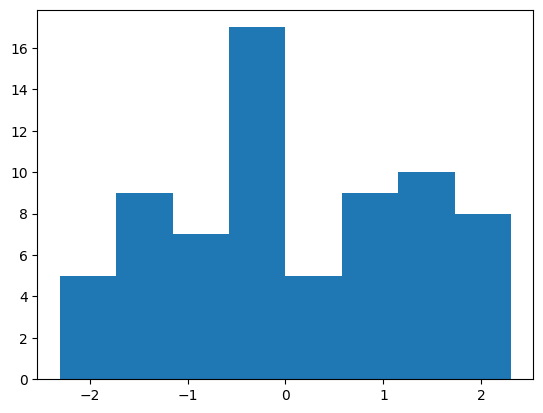

In [15]:
logits = overfit_test(df3.values, 8)
plt.hist(logits, bins='auto')
plt.show()

Do to our relatively small sample the exact shape of the distribution is rather hard to make out. However it seems that there is mass on both sides of zero. Let's calculate the mass on the left to get an estimate of overfit probability.

In [16]:
print(np.mean(logits < 0))

0.5428571428571428


## <u>Question 2</u>

a) Interpet the results above.

b) What other ways might we have to assess the extent of backtest overfitting?

## Testing multiple paths using synthetic data

Having grown slightly skeptical of our initial assessment, we would now like to find an alternative method of evaluating our strategy. One approach we might take is to test several alternate scenarios that might have taken place, instead of relying only on the single historical path that took place.

For machine learning based strategies where we partition the data into training and testing sets, there is a nice combinatorial backtesting method based on the purged cross-validation we explored a few exericses ago. For more on this refer to chapter 12 of Advances in Financial Machine Learning by Marcos Lopes de Prado.

Another alternative is to mathematically describe the process we assume our prices to follow and use it to generate several paths. Ideally, we would like our strategy to peform well regardless of exact market conditions. The exact process we choose depends largely on the security we are dealing with. For our case we will be using geometric brownian motion, familiar from Financial Engineering I.

Let's begin by fitting the parameters of the process to our observed historical price series.

For a refresher on geometric brownian motion see e.g. the wikipedia article:

https://en.wikipedia.org/wiki/Geometric_Brownian_motion

The following Stack Overflow post also provides some insight into parameter estimation for GBM in python:

https://stackoverflow.com/questions/53386933/how-to-solve-fit-a-geometric-brownian-motion-process-in-python

In [17]:
# Parameters are easy to estimat in log-space
log_prices = np.log(df['price'])

# Parameters in log-space
log_mu = log_prices.iloc[-1] - log_prices.iloc[0]
log_sigma = np.sqrt((np.diff(log_prices)**2).sum())

# Transform back
mu = log_mu + 0.5 * log_sigma**2
sigma = log_sigma

We are then ready to simulate several paths. The function below simulates as many paths as the number of initial values provided.

In [18]:
def gbm(mu, sigma, x0, m, dt):
    n = x0.size
    steps = np.zeros((m+1, n))
    steps[0,:] = 1
    steps[1:,:] = np.exp( (mu - sigma**2 / 2) * dt ) * np.exp( sigma * np.random.normal(0, np.sqrt(dt), (m, n)))
    return x0.reshape(1,-1) * steps.cumprod(axis=0)

Let's simulate 500 paths and plot them, along with our original history.

In [19]:
x0 = np.repeat(df['price'].iloc[0], 500)
series = gbm(mu, sigma, x0, df.count().iloc[0]-1, 1/(df.count().iloc[0]-1))

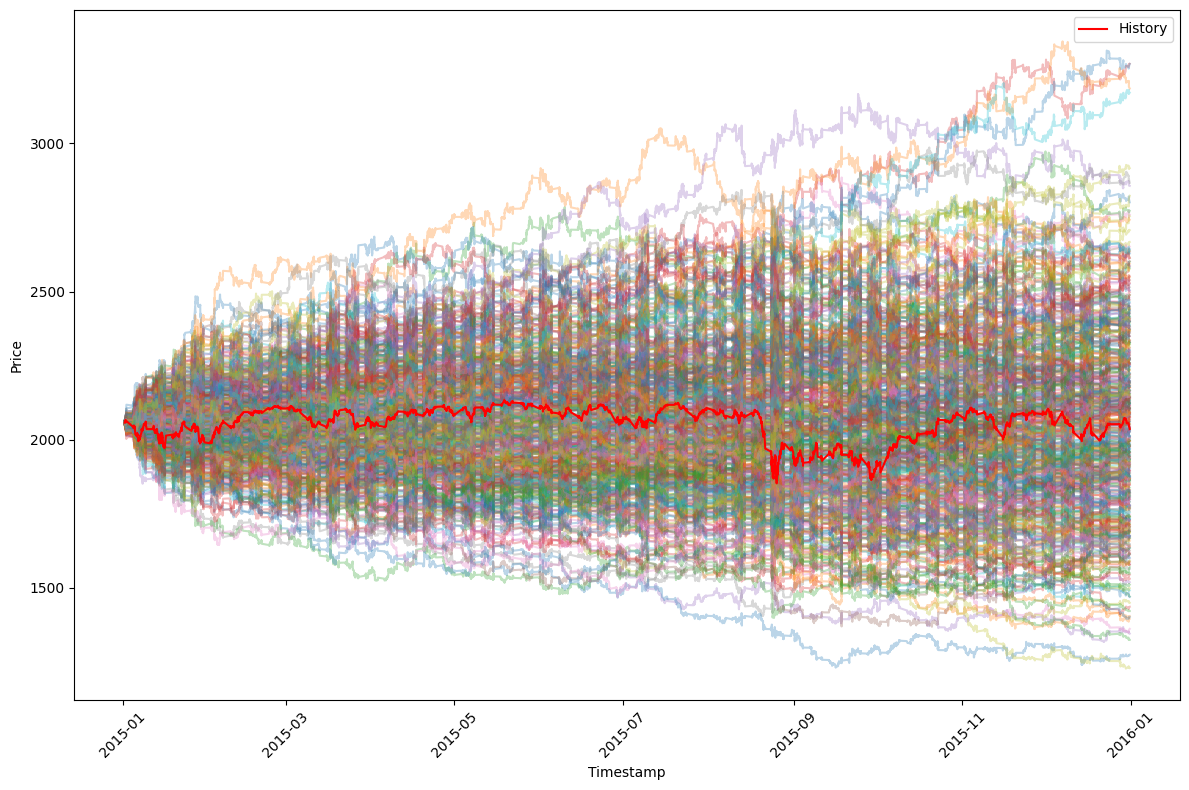

In [20]:
plt.figure(figsize=(12, 8))

plt.plot(df.index, series, alpha=0.3)
plt.plot(df['price'], label='History', color='red')
plt.xlabel('Timestamp')
plt.ylabel(f'Price')
    
# Format x-axis ticks
plt.xticks(rotation=45)
    
plt.tight_layout()
plt.legend()
plt.show()

We can now test the performance of our strategy on each of the paths.

In [21]:
profits = []
for i in range(500):
    df2 = pd.DataFrame(series[:,i])
    df2.columns = ['price']
    profit, returns = crossing(df2, 10, 25)
    profits.append(profit)

In [22]:
def process_column(column, a, b):
    df = pd.DataFrame(column, columns=['price'])
    profit, returns = crossing(df, a, b)
    return profit

# Assuming 'series' is your input array
num_cores = -1  # Use all available cores
profits = Parallel(n_jobs=num_cores)(
    delayed(process_column)(series[:, i], 10, 25) for i in range(series.shape[1])
)

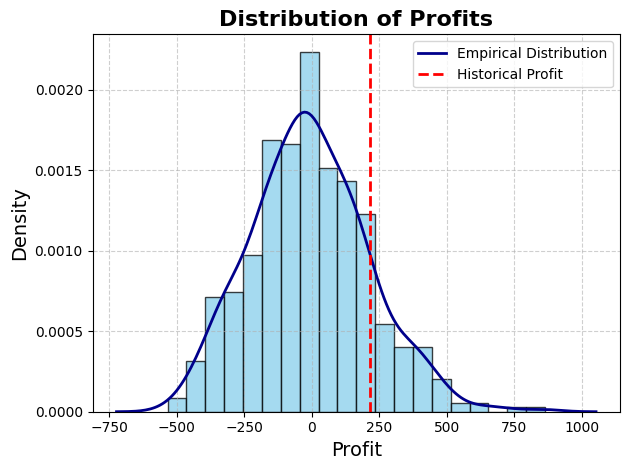

In [23]:
# Create the histogram
plt.hist(profits, density=True, bins='auto', alpha=0.75, color='skyblue', edgecolor='black')

# Add a Kernel Density Estimate (KDE) line
sns.kdeplot(profits, color='darkblue', linewidth=2, label='Empirical Distribution')

# Add a vertical line for the historical profit
plt.axvline(historical_profit, color='red', linestyle='--', linewidth=2, label='Historical Profit')

# Titles and labels
plt.title('Distribution of Profits', fontsize=16, fontweight='bold')
plt.xlabel('Profit', fontsize=14)
plt.ylabel('Density', fontsize=14)

# Add a legend
plt.legend()

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.tight_layout()
plt.show()


## <u> Question 3 </u>

a) What do the results above tell us?

b) What properties of the price of a security might be relevant when choosing the process to model it? Find some alternative processes and the securities they are well suited to model.